Top rank precipitation plots over 8 regions
Ming Ge April 2025

In [1]:
import os
import math
import pickle
import xarray as xr
import datetime
from tqdm import tqdm
from netCDF4 import Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cartopy 
import cartopy.feature as cfeature
import cartopy.crs as ccrs


![8 EU regions](IMG/eu_regions.png)

In [2]:

dir_d = '/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/'
dir_o = '/glade/campaign/mmm/c3we/mingge/FRONTIERS/PAPER/'

# for CERRA
year_s = 1990
year_e = 2010
n_year = year_e - year_s + 1

# ds_1d has to be like this 
ds_1d = ['CERRA', 'EUR-11', 'EUR-44']
n_d = len(ds_1d)

DataName_1d = ['CERRA', 
               'CLMcom-ETH', 
               'MOHC-HadREM3',
               'ICTP-RegCM4',
               'CLMcom-CCLM5', 
               'MOHC-HadGEM3-RA',
               'UCAN-WRF331G']

color_1d = ['black', 'blue', 'royalblue','cornflowerblue','indianred','lightcoral','sandybrown']

rank_1d = ['10', '20', '50', '100', '150', '200', '300', '400', '600']
n_rank = len(rank_1d)

loc_1d   = ["BI", "IP", "FR", "ME", "SC", "AL", "MD", "EA"]
west_1d  =   [-10,  -10,  -5,   2,    5,    5,    3,    16]
east_1d  =   [2,     3,     5,   16,   30,   15,   25,   30]
south_1d =   [50,    36,   44,   48,   55,   44,   36,   44]
north_1d =   [59,    44,   50,   55,   70,   48,   44,   55]
    
n_loc = len(loc_1d)
n_dataset = len(DataName_1d)

data_3d = np.zeros((n_loc, n_dataset, n_rank))
for nr in range(n_rank):
    for nd in range(n_d):
        var_s = 'prec_' + str(rank_1d[nr]) + 'th'
        flnm = dir_d + var_s + '_' + ds_1d[nd] + '.nc'
        print(flnm)
        with xr.open_dataset(flnm) as ds:
            #print(ds)
            lat2d = ds['lat_2d']
            lon2d = ds['lon_2d']
            
            for nl in range(n_loc):
                # Create a mask where condition is True INSIDE the region
                mask = (
                    (lat2d >= south_1d[nl]) & (lat2d <= north_1d[nl]) &
                    (lon2d >= west_1d[nl]) & (lon2d <= east_1d[nl])
                )
                masked_data = ds[var_s].where(mask).mean(dim=['lat', 'lon']) 
                #print(masked_data.data)
                # CERRA
                if nd == 0:
                    data_3d[nl, 0, nr] = masked_data.data
                elif nd == 1:
                    data_3d[nl, 1:4, nr] = masked_data.data
                elif nd == 2:
                    data_3d[nl, 4:, nr] = masked_data.data
                

/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_10th_CERRA.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_10th_EUR-11.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_10th_EUR-44.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_20th_CERRA.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_20th_EUR-11.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_20th_EUR-44.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_50th_CERRA.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_50th_EUR-11.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_50th_EUR-44.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_100th_CERRA.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_100th_EUR-11.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_100th_EUR-44.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_150th_CERRA.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_150th_EUR-11.nc
/glade/campaign/mmm/c3we/mingge/FRONTIERS/data/prec_150th_EUR-

#### calculate daily maximum precipitation of each region

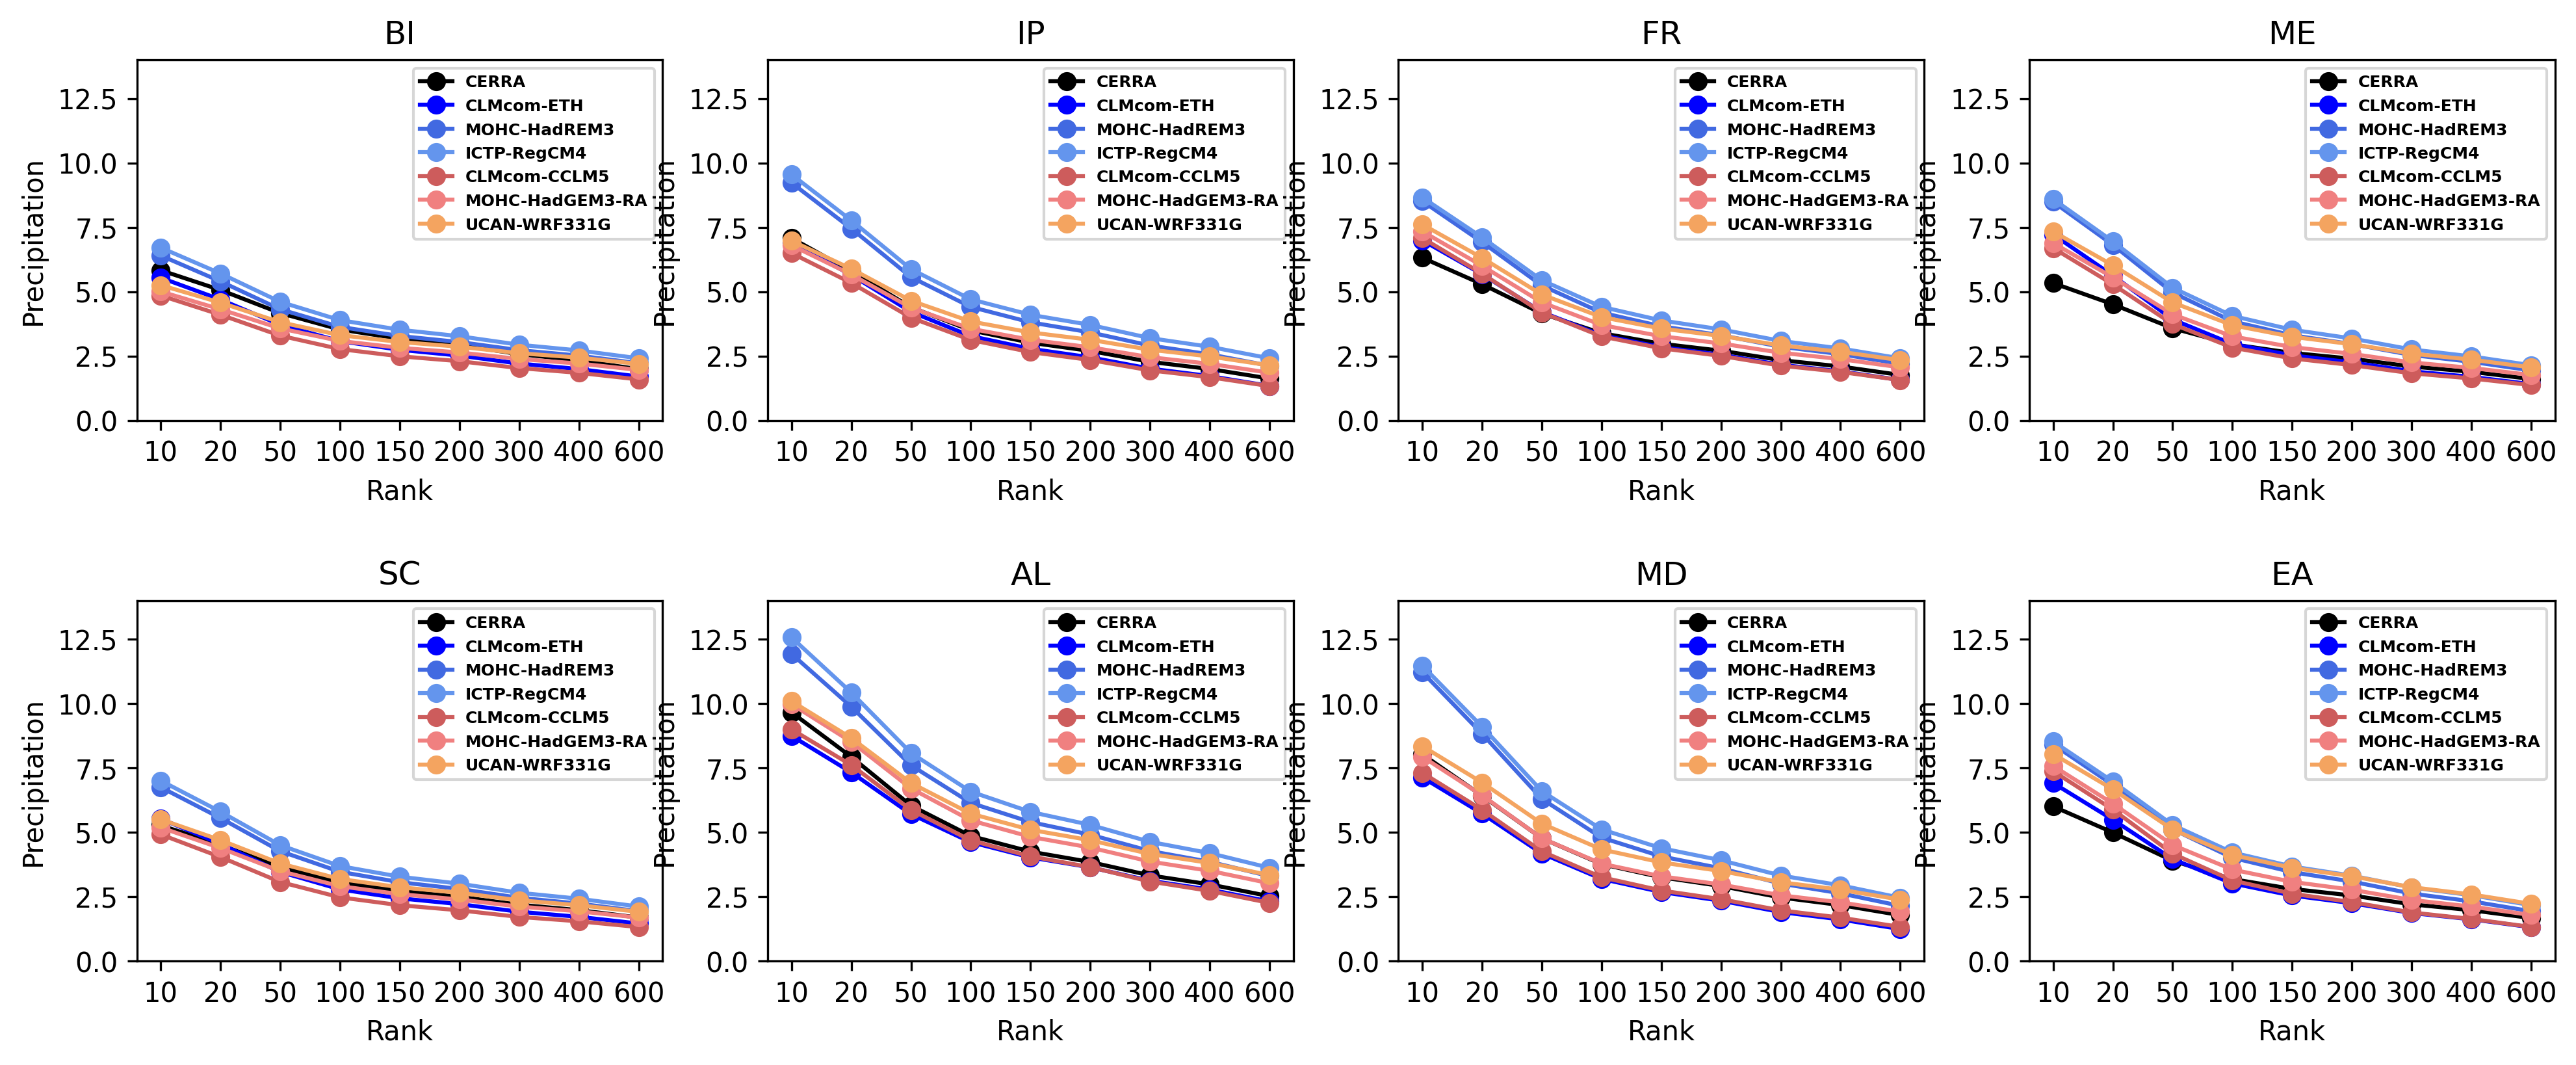

In [10]:
# Create 8 subplots in a 2-row x 4-column layout
fig, axs = plt.subplots(2, 4, figsize=(16, 6), dpi=300)  # 2 rows, 4 columns

# Flatten axs array to easily loop over it
axs = axs.flatten()

#data_3d = np.zeros((n_loc, n_dataset, n_rank))
for nl in range(n_loc):
    for i in range(data_3d[nl].shape[0]):
        axs[nl].plot(data_3d[nl,i], label=DataName_1d[i], marker='o', color=color_1d[i])
        # Custom x-axis tick labels
        axs[nl].set_xticks(np.arange(len(rank_1d)).tolist())
        axs[nl].set_xticklabels(rank_1d)
    
    axs[nl].legend(prop={'size': 6, 'weight': 'bold'})
    axs[nl].set_title(loc_1d[nl])
    axs[nl].set_ylim(0, 14)
    axs[nl].set_xlabel('Rank')
    axs[nl].set_ylabel('Precipitation')

# Increase vertical space between rows
plt.subplots_adjust(hspace=0.5)